<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/ThermodynamicsOfAmmonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thermodynamics of ammonia with NeqSim

**Audience.** Process, energy, and refrigeration engineers who need a reproducible introduction
to pure-ammonia phase equilibrium and energy calculations.

**Prerequisites.** Introductory thermodynamics, basic Python, and familiarity with pressure,
temperature, enthalpy, and phase equilibrium.

**Learning objectives**

- build a pure-ammonia fluid with a supported NeqSim equation of state;
- calculate critical constants, normal boiling temperature, and a saturation curve;
- compare vapour pressure and latent heat with public NIST reference data;
- verify the Clapeyron equation from independent NeqSim properties;
- quantify equation-of-state uncertainty and validity limits;
- connect fluids, streams, and a heater in a small process model; and
- close energy balances and interpret heating sensitivities.

This notebook treats **pure anhydrous ammonia**. Water-ammonia mixtures, synthesis, and complete
refrigeration cycles require different compositions and process models and are outside its scope.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "--quiet",
            "neqsim",
        ]
    )
    neqsim_version = importlib.metadata.version("neqsim")

print(f"NeqSim version: {neqsim_version}")

NeqSim version: 3.16.0


## 1. NeqSim architecture and unit conventions

A NeqSim fluid object contains components, mole amounts, temperature, pressure, phases, and an
equation of state. `ThermodynamicOperations` applies a flash calculation, such as a TP flash or a
bubble-point flash. A stream carries a cloned thermodynamic state and a flow rate. Unit operations
take inlet streams, impose specifications, and solve outlet states. `runProcess()` executes the
flowsheet in connection order.

Displayed quantities use SI units: temperature in K, absolute pressure in MPa, density in
kg/m³, molar volume in m³/mol, molar energy in kJ/mol, mass-specific energy in kJ/kg, mass flow in
kg/s, and duty in kW. NeqSim's pressure setter accepts `bara`; this notebook converts every
reported pressure using $1\ \mathrm{bar}=0.1\ \mathrm{MPa}$.

In [2]:
import math

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.process import clearProcess, heater, runProcess, stream
from neqsim.thermo import fluid


plt.style.use("seaborn-v0_8-whitegrid")
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)

python_version = sys.version.split()[0]
java_version = jpype.JClass("java.lang.System").getProperty("java.version")

print(f"Python version: {python_version}")
print(f"Java version: {java_version}")

Python version: 3.12.13
Java version: 17.0.19


## 2. Model choice, assumptions, and reusable helpers

The primary model is Peng-Robinson (PR). It is available through the current public Python API,
is computationally efficient, and reproduces the public ammonia vapour-pressure data used below
within a few percent over the demonstrated range. Soave-Redlich-Kwong (SRK) is retained as an
independent cubic-EOS comparison.

For PR, pressure $P$ follows

$$
P=\frac{RT}{v-b}-\frac{a\alpha}{v(v+b)+b(v-b)}
$$

where $R$ is the gas constant, $T$ is temperature in K, $v$ is molar volume in m³/mol, and
$a$, $b$, and $\alpha$ are component and temperature parameters. The calculation assumes pure,
anhydrous ammonia at equilibrium, with no non-condensable gas, water, reaction, or pressure drop.
Near-critical properties and electrolyte-containing mixtures require dedicated validation.

In [3]:
def make_ammonia(model="pr", temperature_kelvin=300.0, pressure_bara=1.0):
    state = fluid(
        model,
        temperature=temperature_kelvin,
        pressure=pressure_bara,
    )
    state.addComponent("ammonia", 1.0)
    state.setMultiPhaseCheck(True)
    return state


def run_tp_flash(state):
    operations = ThermodynamicOperations(state)
    operations.TPflash()
    state.initProperties()
    return state


def saturated_state(temperature_kelvin, model="pr"):
    state = make_ammonia(
        model=model,
        temperature_kelvin=temperature_kelvin,
        pressure_bara=1.0,
    )
    operations = ThermodynamicOperations(state)
    operations.bubblePointPressureFlash()
    state.initProperties()
    return state


def density_ordered_phases(state):
    phases = [
        state.getPhase(phase_index)
        for phase_index in range(state.getNumberOfPhases())
    ]
    ordered_phases = sorted(
        phases,
        key=lambda phase: phase.getDensity("kg/m3"),
    )
    vapour_phase = ordered_phases[0]
    liquid_phase = ordered_phases[-1]
    return vapour_phase, liquid_phase

## 3. Component constants and domain checks

Critical constants are stored with the component data. Above the critical temperature, distinct
liquid and vapour phases cannot coexist. These database values are inputs to the EOS calculation,
so agreement here checks component identity and units rather than independently validating the
equation of state.

The public reference values used here are $T_c=405.4\ \mathrm{K}$ and
$P_c=11.300\ \mathrm{MPa}$.

In [4]:
reference_critical_temperature_kelvin = 405.4
reference_critical_pressure_mpa = 11.300

component_state = make_ammonia()
ammonia_component = component_state.getPhase(0).getComponent("ammonia")

critical_temperature_kelvin = ammonia_component.getTC()
critical_pressure_mpa = ammonia_component.getPC() * 0.1

critical_table = pd.DataFrame(
    {
        "Quantity": ["Critical temperature", "Critical pressure"],
        "NeqSim value": [critical_temperature_kelvin, critical_pressure_mpa],
        "Reference value": [
            reference_critical_temperature_kelvin,
            reference_critical_pressure_mpa,
        ],
        "Unit": ["K", "MPa absolute"],
    }
)

print(critical_table.to_string(index=False))

            Quantity  NeqSim value  Reference value         Unit
Critical temperature         405.4            405.4            K
   Critical pressure          11.3             11.3 MPa absolute


## 4. Normal boiling temperature

At the normal boiling point, the bubble pressure equals standard atmospheric pressure. Phase
equilibrium requires equal ammonia fugacity in the liquid and vapour:

$$
f_{\mathrm{NH_3}}^{L}=f_{\mathrm{NH_3}}^{V}
$$

The bubble-temperature solver changes $T$ at fixed $P=0.101325\ \mathrm{MPa}$ until this equality
is met. NIST reports a normal boiling temperature near 239.82 K.

In [5]:
standard_pressure_bara = 1.01325
reference_boiling_temperature_kelvin = 239.82

normal_boiling_state = make_ammonia(
    temperature_kelvin=240.0,
    pressure_bara=standard_pressure_bara,
)
normal_boiling_operations = ThermodynamicOperations(normal_boiling_state)
normal_boiling_operations.bubblePointTemperatureFlash()

normal_boiling_temperature_kelvin = normal_boiling_state.getTemperature("K")
boiling_temperature_error_kelvin = (
    normal_boiling_temperature_kelvin
    - reference_boiling_temperature_kelvin
)

print(
    "PR normal boiling temperature: "
    f"{normal_boiling_temperature_kelvin:.3f} K"
)
print(
    "Difference from NIST reference: "
    f"{boiling_temperature_error_kelvin:+.3f} K"
)

PR normal boiling temperature: 239.610 K
Difference from NIST reference: -0.210 K


## 5. Vapour pressure and the reference correlation

NIST gives an Antoine correlation for ammonia from 239.6 K to 371.5 K:

$$
\log_{10}(P_{\mathrm{bar}})=A-\frac{B}{T+C}
$$

Here $P_{\mathrm{bar}}$ is absolute pressure in bar, $T$ is in K, and the coefficients are
$A=4.86886$, $B=1113.928\ \mathrm{K}$, and $C=-10.409\ \mathrm{K}$. We stop the NeqSim comparison
at 350 K, well below the 405.4 K critical point, because cubic-EOS saturation solvers become
increasingly sensitive to initial conditions near criticality.

In [6]:
antoine_a = 4.86886
antoine_b_kelvin = 1113.928
antoine_c_kelvin = -10.409


def nist_antoine_pressure_mpa(temperature_kelvin):
    pressure_bar = 10.0 ** (
        antoine_a
        - antoine_b_kelvin / (temperature_kelvin + antoine_c_kelvin)
    )
    return pressure_bar * 0.1


saturation_temperatures_kelvin = np.arange(240.0, 351.0, 10.0)
saturation_records = []

for temperature_kelvin in saturation_temperatures_kelvin:
    equilibrium_state = saturated_state(temperature_kelvin)
    neqsim_pressure_mpa = equilibrium_state.getPressure("bara") * 0.1
    reference_pressure_mpa = nist_antoine_pressure_mpa(temperature_kelvin)
    relative_error_percent = 100.0 * (
        neqsim_pressure_mpa - reference_pressure_mpa
    ) / reference_pressure_mpa

    saturation_records.append(
        {
            "Temperature [K]": temperature_kelvin,
            "NeqSim PR pressure [MPa abs]": neqsim_pressure_mpa,
            "NIST Antoine pressure [MPa abs]": reference_pressure_mpa,
            "Relative difference [%]": relative_error_percent,
        }
    )

saturation_table = pd.DataFrame(saturation_records)
print(saturation_table.round(4).to_string(index=False))

 Temperature [K]  NeqSim PR pressure [MPa abs]  NIST Antoine pressure [MPa abs]  Relative difference [%]
           240.0                        0.1033                           0.1040                  -0.6571
           250.0                        0.1666                           0.1658                   0.4738
           260.0                        0.2576                           0.2546                   1.1876
           270.0                        0.3842                           0.3782                   1.5725
           280.0                        0.5550                           0.5457                   1.7076
           290.0                        0.7796                           0.7669                   1.6624
           300.0                        1.0684                           1.0527                   1.4960
           310.0                        1.4326                           1.4148                   1.2583
           320.0                        1.8840         

The pressure must rise monotonically with temperature. Agreement with a reference correlation is
a model check, not a parameter fit: the Antoine values are calculated independently of NeqSim.
The small systematic differences are a useful reminder that a cubic EOS is an engineering model,
not a property standard.

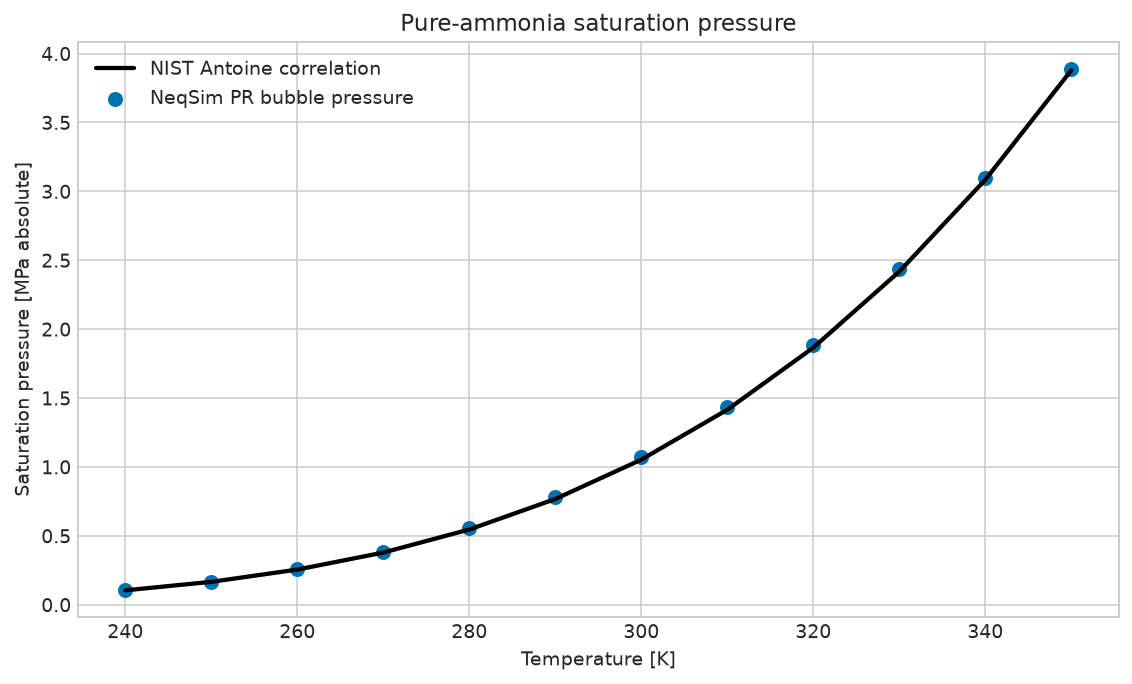

In [7]:
figure, pressure_axis = plt.subplots(figsize=(8.2, 5.0))

pressure_axis.plot(
    saturation_table["Temperature [K]"],
    saturation_table["NIST Antoine pressure [MPa abs]"],
    color="black",
    linewidth=2.2,
    label="NIST Antoine correlation",
)
pressure_axis.scatter(
    saturation_table["Temperature [K]"],
    saturation_table["NeqSim PR pressure [MPa abs]"],
    color="#0072B2",
    s=45,
    label="NeqSim PR bubble pressure",
)
pressure_axis.set_xlabel("Temperature [K]")
pressure_axis.set_ylabel("Saturation pressure [MPa absolute]")
pressure_axis.set_title("Pure-ammonia saturation pressure")
pressure_axis.legend()

figure.tight_layout()
plt.show()

## 6. Saturated-phase properties and latent heat

At each bubble state, the lower-density phase is identified as vapour and the higher-density phase
as liquid. Density ordering is more robust than assuming a fixed phase index. The molar enthalpy
of vaporization is

$$
\Delta h_{\mathrm{vap}}=h^{V}-h^{L}
$$

where $h^V$ and $h^L$ are in kJ/mol. Latent heat should be positive and decrease as the critical
point is approached.

In [8]:
property_temperatures_kelvin = [240.0, 280.0, 320.0, 350.0]
phase_property_records = []

for temperature_kelvin in property_temperatures_kelvin:
    equilibrium_state = saturated_state(temperature_kelvin)
    vapour_phase, liquid_phase = density_ordered_phases(equilibrium_state)

    vapour_enthalpy_j_per_mol = vapour_phase.getEnthalpy("J/mol")
    liquid_enthalpy_j_per_mol = liquid_phase.getEnthalpy("J/mol")
    latent_heat_kj_per_mol = (
        vapour_enthalpy_j_per_mol - liquid_enthalpy_j_per_mol
    ) / 1000.0

    phase_property_records.append(
        {
            "Temperature [K]": temperature_kelvin,
            "Pressure [MPa abs]": equilibrium_state.getPressure("bara") * 0.1,
            "Liquid density [kg/m³]": liquid_phase.getDensity("kg/m3"),
            "Vapour density [kg/m³]": vapour_phase.getDensity("kg/m3"),
            "Latent heat [kJ/mol]": latent_heat_kj_per_mol,
        }
    )

phase_property_table = pd.DataFrame(phase_property_records)
print(phase_property_table.round(4).to_string(index=False))

 Temperature [K]  Pressure [MPa abs]  Liquid density [kg/m³]  Vapour density [kg/m³]  Latent heat [kJ/mol]
           240.0              0.1033                885.6077                  0.8960               23.5611
           280.0              0.5550                793.9416                  4.3134               21.5567
           320.0              1.8840                681.1672                 14.1515               18.8220
           350.0              3.8907                576.2469                 30.5863               15.8656


NIST reports an ammonia enthalpy of vaporization of 23.5 kJ/mol at 239 K. This point is useful
because it checks a caloric property in addition to vapour pressure. The comparison is kept at the
published temperature rather than silently shifting it to the model's boiling temperature.

In [9]:
latent_reference_temperature_kelvin = 239.0
reference_latent_heat_kj_per_mol = 23.5

latent_reference_state = saturated_state(latent_reference_temperature_kelvin)
reference_vapour_phase, reference_liquid_phase = density_ordered_phases(
    latent_reference_state
)
model_latent_heat_kj_per_mol = (
    reference_vapour_phase.getEnthalpy("J/mol")
    - reference_liquid_phase.getEnthalpy("J/mol")
) / 1000.0
latent_heat_error_percent = 100.0 * (
    model_latent_heat_kj_per_mol - reference_latent_heat_kj_per_mol
) / reference_latent_heat_kj_per_mol

print(f"NeqSim PR latent heat at 239 K: {model_latent_heat_kj_per_mol:.3f} kJ/mol")
print(f"NIST reference at 239 K: {reference_latent_heat_kj_per_mol:.3f} kJ/mol")
print(f"Relative difference: {latent_heat_error_percent:+.3f} %")

NeqSim PR latent heat at 239 K: 23.606 kJ/mol
NIST reference at 239 K: 23.500 kJ/mol
Relative difference: +0.450 %


## 7. Independent Clapeyron verification

For pure-component coexistence, the Clapeyron equation links the slope of the saturation curve to
latent heat and the molar-volume change:

$$
\frac{dP_{\mathrm{sat}}}{dT}
=\frac{\Delta h_{\mathrm{vap}}}{T(v^{V}-v^{L})}
$$

Pressure is in Pa, temperature in K, enthalpy in J/mol, and molar volume in m³/mol, so both sides
have units Pa/K. A centred finite difference of independently calculated bubble pressures provides
the left-hand side.

In [10]:
clapeyron_temperature_kelvin = 300.0
temperature_step_kelvin = 0.25

lower_state = saturated_state(
    clapeyron_temperature_kelvin - temperature_step_kelvin
)
upper_state = saturated_state(
    clapeyron_temperature_kelvin + temperature_step_kelvin
)
central_state = saturated_state(clapeyron_temperature_kelvin)

pressure_slope_pa_per_kelvin = (
    upper_state.getPressure("bara") - lower_state.getPressure("bara")
) * 1.0e5 / (2.0 * temperature_step_kelvin)

central_vapour_phase, central_liquid_phase = density_ordered_phases(central_state)
latent_heat_j_per_mol = (
    central_vapour_phase.getEnthalpy("J/mol")
    - central_liquid_phase.getEnthalpy("J/mol")
)
volume_change_m3_per_mol = (
    central_vapour_phase.getMolarVolume("m3/mol")
    - central_liquid_phase.getMolarVolume("m3/mol")
)
clapeyron_slope_pa_per_kelvin = latent_heat_j_per_mol / (
    clapeyron_temperature_kelvin * volume_change_m3_per_mol
)
clapeyron_residual_percent = 100.0 * (
    pressure_slope_pa_per_kelvin - clapeyron_slope_pa_per_kelvin
) / clapeyron_slope_pa_per_kelvin

print(f"Finite-difference slope: {pressure_slope_pa_per_kelvin:,.2f} Pa/K")
print(f"Clapeyron slope: {clapeyron_slope_pa_per_kelvin:,.2f} Pa/K")
print(f"Relative residual: {clapeyron_residual_percent:+.6f} %")

Finite-difference slope: 32,457.47 Pa/K
Clapeyron slope: 32,457.35 Pa/K
Relative residual: +0.000369 %


## 8. Equation-of-state sensitivity

PR and SRK share a cubic-EOS structure but use different attraction terms. Their spread is a
simple model-form sensitivity, not a confidence interval. Both calculations use the same ammonia
component data, temperature grid, bubble-point solver, and units.

In [11]:
comparison_temperatures_kelvin = [240.0, 280.0, 320.0, 350.0]
model_comparison_records = []

for temperature_kelvin in comparison_temperatures_kelvin:
    reference_pressure_mpa = nist_antoine_pressure_mpa(temperature_kelvin)

    for model_name in ["pr", "srk"]:
        model_state = saturated_state(
            temperature_kelvin,
            model=model_name,
        )
        model_pressure_mpa = model_state.getPressure("bara") * 0.1
        error_percent = 100.0 * (
            model_pressure_mpa - reference_pressure_mpa
        ) / reference_pressure_mpa

        model_comparison_records.append(
            {
                "Temperature [K]": temperature_kelvin,
                "Model": model_name.upper(),
                "Pressure [MPa abs]": model_pressure_mpa,
                "Difference from NIST [%]": error_percent,
            }
        )

model_comparison_table = pd.DataFrame(model_comparison_records)
print(model_comparison_table.round(4).to_string(index=False))

 Temperature [K] Model  Pressure [MPa abs]  Difference from NIST [%]
           240.0    PR              0.1033                   -0.6571
           240.0   SRK              0.1008                   -3.1252
           280.0    PR              0.5550                    1.7076
           280.0   SRK              0.5559                    1.8780
           320.0    PR              1.8840                    0.9905
           320.0   SRK              1.9070                    2.2251
           350.0    PR              3.8907                    0.3159
           350.0   SRK              3.9404                    1.5982


PR is retained for the rest of the notebook because its maximum absolute vapour-pressure
difference is smaller on these check points. Model selection should be revisited for wider ranges,
mixtures, electrolyte systems, and design guarantees.

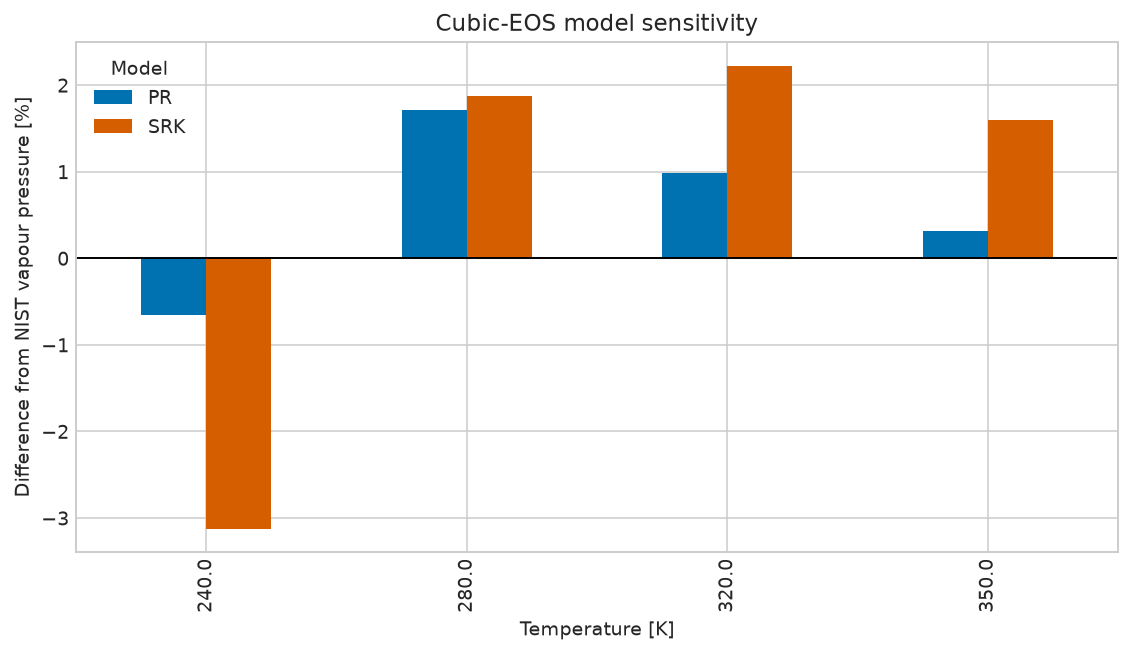

In [12]:
comparison_pivot = model_comparison_table.pivot(
    index="Temperature [K]",
    columns="Model",
    values="Difference from NIST [%]",
)

figure, error_axis = plt.subplots(figsize=(8.2, 4.8))
comparison_pivot.plot(
    kind="bar",
    ax=error_axis,
    color=["#0072B2", "#D55E00"],
)
error_axis.axhline(0.0, color="black", linewidth=1.0)
error_axis.set_xlabel("Temperature [K]")
error_axis.set_ylabel("Difference from NIST vapour pressure [%]")
error_axis.set_title("Cubic-EOS model sensitivity")
error_axis.legend(title="Model")

figure.tight_layout()
plt.show()

## 9. Isobaric heating and phase interpretation

At fixed pressure, a pure fluid changes from subcooled liquid to superheated vapour at its
saturation temperature. A TP flash determines the stable phase at each specified state. The sharp
enthalpy jump across the boiling interval is physical latent heat; it is not a numerical spike.

The following path uses $P=2.0\ \mathrm{MPa}$ absolute. Kinetic and potential energy are neglected.

In [13]:
heating_pressure_bara = 20.0
heating_temperatures_kelvin = np.arange(280.0, 341.0, 5.0)
heating_path_records = []

for temperature_kelvin in heating_temperatures_kelvin:
    heating_state = make_ammonia(
        temperature_kelvin=temperature_kelvin,
        pressure_bara=heating_pressure_bara,
    )
    run_tp_flash(heating_state)

    phase_names = [
        str(heating_state.getPhase(index).getPhaseTypeName())
        for index in range(heating_state.getNumberOfPhases())
    ]
    heating_path_records.append(
        {
            "Temperature [K]": temperature_kelvin,
            "Pressure [MPa abs]": heating_state.getPressure("bara") * 0.1,
            "Enthalpy [kJ/kg]": heating_state.getEnthalpy("kJ/kg"),
            "Phase": "+".join(phase_names),
        }
    )

heating_path_table = pd.DataFrame(heating_path_records)
print(heating_path_table.to_string(index=False))

 Temperature [K]  Pressure [MPa abs]  Enthalpy [kJ/kg]   Phase
           280.0                 2.0      -1268.591102 aqueous
           285.0                 2.0      -1242.469695 aqueous
           290.0                 2.0      -1215.981410 aqueous
           295.0                 2.0      -1189.093606 aqueous
           300.0                 2.0      -1161.769093 aqueous
           305.0                 2.0      -1133.965048 aqueous
           310.0                 2.0      -1105.631562 aqueous
           315.0                 2.0      -1076.709697 aqueous
           320.0                 2.0      -1047.128813 aqueous
           325.0                 2.0         69.077582     gas
           330.0                 2.0         84.628059     gas
           335.0                 2.0        100.171824     gas
           340.0                 2.0        115.720348     gas


The phase label `aqueous` is NeqSim's liquid-phase family name for this polar pure fluid; it does
not mean that water was added. The composition remains one mole fraction ammonia at every state.
For calculations that need an exact two-phase quality, specify pressure plus enthalpy or perform a
dedicated saturation calculation rather than reading quality from a coarse temperature grid.

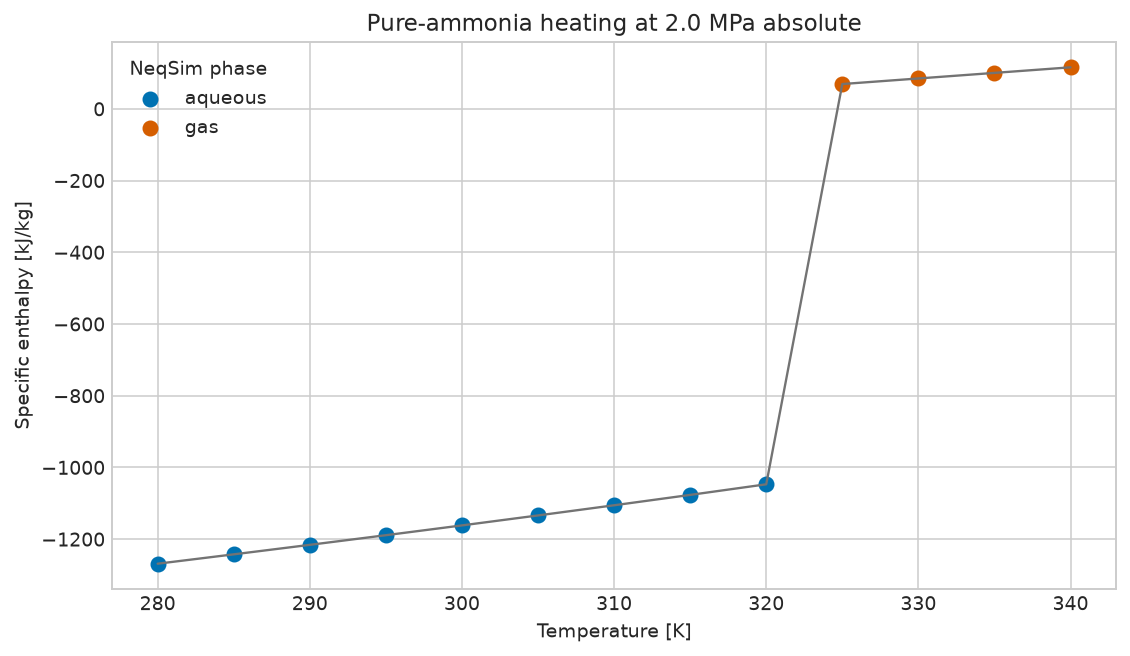

In [14]:
figure, enthalpy_axis = plt.subplots(figsize=(8.2, 4.8))

phase_colours = {
    "aqueous": "#0072B2",
    "gas": "#D55E00",
}

for phase_name, phase_group in heating_path_table.groupby("Phase"):
    enthalpy_axis.scatter(
        phase_group["Temperature [K]"],
        phase_group["Enthalpy [kJ/kg]"],
        color=phase_colours.get(phase_name, "#009E73"),
        s=52,
        label=phase_name,
    )

enthalpy_axis.plot(
    heating_path_table["Temperature [K]"],
    heating_path_table["Enthalpy [kJ/kg]"],
    color="0.45",
    linewidth=1.2,
)
enthalpy_axis.set_xlabel("Temperature [K]")
enthalpy_axis.set_ylabel("Specific enthalpy [kJ/kg]")
enthalpy_axis.set_title("Pure-ammonia heating at 2.0 MPa absolute")
enthalpy_axis.legend(title="NeqSim phase")

figure.tight_layout()
plt.show()

## 10. From a fluid to a process heater

The steady-flow energy balance for an adiabatic pressure-preserving heater is

$$
\dot Q=\dot m(h_{\mathrm{out}}-h_{\mathrm{in}})
$$

Here $\dot Q$ is heat input in kW, $\dot m$ is mass flow in kg/s, and $h$ is specific enthalpy in
kJ/kg. NeqSim's stream carries the PR fluid and flow rate; the heater specifies outlet temperature;
the process solver executes the connected units.

In [15]:
clearProcess()

feed_temperature_kelvin = 280.0
outlet_temperature_kelvin = 330.0
process_pressure_bara = 20.0
mass_flow_kg_per_s = 0.5

process_fluid = make_ammonia(
    temperature_kelvin=feed_temperature_kelvin,
    pressure_bara=process_pressure_bara,
)
feed_stream = stream("anhydrous ammonia feed", process_fluid)
feed_stream.setFlowRate(mass_flow_kg_per_s, "kg/sec")

process_heater = heater("ammonia vaporizer", feed_stream)
process_heater.setOutTemperature(outlet_temperature_kelvin, "K")

runProcess()

inlet_system = feed_stream.getThermoSystem()
outlet_system = process_heater.getOutletStream().getThermoSystem()
inlet_enthalpy_kj_per_kg = inlet_system.getEnthalpy("kJ/kg")
outlet_enthalpy_kj_per_kg = outlet_system.getEnthalpy("kJ/kg")
heater_duty_kw = process_heater.getDuty("kW")
manual_heater_duty_kw = mass_flow_kg_per_s * (
    outlet_enthalpy_kj_per_kg - inlet_enthalpy_kj_per_kg
)
heater_balance_residual_kw = heater_duty_kw - manual_heater_duty_kw

print(f"Inlet temperature: {feed_stream.getTemperature('K'):.2f} K")
print(f"Outlet temperature: {process_heater.getOutletStream().getTemperature('K'):.2f} K")
print(f"Pressure: {outlet_system.getPressure('bara') * 0.1:.3f} MPa absolute")
print(f"Heater duty: {heater_duty_kw:.3f} kW")
print(f"Energy-balance residual: {heater_balance_residual_kw:.3e} kW")

Inlet temperature: 280.00 K
Outlet temperature: 330.00 K
Pressure: 2.000 MPa absolute
Heater duty: 676.610 kW
Energy-balance residual: 1.137e-13 kW


## 11. Outlet-temperature sensitivity

The same inlet is heated to several targets. Each case creates a fresh process so no hidden state
is carried between scenarios. Duty should increase with target temperature, with a large increment
when vaporization occurs. This is an equilibrium screening calculation: heat-transfer area,
pinch temperature, dynamics, and pressure drop are not sized.

In [16]:
outlet_targets_kelvin = [295.0, 315.0, 325.0, 340.0]
heater_sensitivity_records = []

for target_temperature_kelvin in outlet_targets_kelvin:
    clearProcess()

    scenario_fluid = make_ammonia(
        temperature_kelvin=feed_temperature_kelvin,
        pressure_bara=process_pressure_bara,
    )
    scenario_feed = stream("scenario ammonia feed", scenario_fluid)
    scenario_feed.setFlowRate(mass_flow_kg_per_s, "kg/sec")

    scenario_heater = heater("scenario ammonia heater", scenario_feed)
    scenario_heater.setOutTemperature(target_temperature_kelvin, "K")
    runProcess()

    scenario_outlet = scenario_heater.getOutletStream().getThermoSystem()
    scenario_phases = [
        str(scenario_outlet.getPhase(index).getPhaseTypeName())
        for index in range(scenario_outlet.getNumberOfPhases())
    ]
    heater_sensitivity_records.append(
        {
            "Outlet temperature [K]": target_temperature_kelvin,
            "Heater duty [kW]": scenario_heater.getDuty("kW"),
            "Outlet phase": "+".join(scenario_phases),
        }
    )

heater_sensitivity_table = pd.DataFrame(heater_sensitivity_records)
print(heater_sensitivity_table.round(3).to_string(index=False))

 Outlet temperature [K]  Heater duty [kW] Outlet phase
                  295.0            39.749      aqueous
                  315.0            95.941      aqueous
                  325.0           668.834          gas
                  340.0           692.156          gas


## 12. Verification checks

The checks combine database identity, public benchmarks, thermodynamic identities, expected
trends, finiteness, and a process energy balance. Thresholds are deliberately wider than numerical
roundoff where model-form uncertainty is involved. A failed assertion should be investigated, not
removed to make the notebook run.

In [17]:
saturation_pressures_mpa = saturation_table[
    "NeqSim PR pressure [MPa abs]"
].to_numpy()
liquid_densities = phase_property_table[
    "Liquid density [kg/m³]"
].to_numpy()
vapour_densities = phase_property_table[
    "Vapour density [kg/m³]"
].to_numpy()
latent_heats = phase_property_table[
    "Latent heat [kJ/mol]"
].to_numpy()
sensitivity_duties_kw = heater_sensitivity_table[
    "Heater duty [kW]"
].to_numpy()
sensitivity_phases = heater_sensitivity_table["Outlet phase"].tolist()

verification_checks = {
    "NeqSim version recorded": bool(neqsim_version),
    "critical temperature identity": abs(
        critical_temperature_kelvin - reference_critical_temperature_kelvin
    ) < 0.05,
    "critical pressure identity": abs(
        critical_pressure_mpa - reference_critical_pressure_mpa
    ) < 0.005,
    "normal boiling benchmark": abs(boiling_temperature_error_kelvin) < 1.0,
    "saturation pressure monotonic": bool(np.all(np.diff(saturation_pressures_mpa) > 0.0)),
    "vapour-pressure benchmark": float(
        saturation_table["Relative difference [%]"].abs().max()
    ) < 3.0,
    "liquid denser than vapour": bool(np.all(liquid_densities > vapour_densities)),
    "positive latent heat": bool(np.all(latent_heats > 0.0)),
    "latent heat decreases": bool(np.all(np.diff(latent_heats) < 0.0)),
    "latent-heat benchmark": abs(latent_heat_error_percent) < 2.0,
    "Clapeyron consistency": abs(clapeyron_residual_percent) < 0.1,
    "finite saturation properties": bool(
        np.isfinite(phase_property_table.select_dtypes(include=[float, int])).all().all()
    ),
    "model comparison finite": bool(
        np.isfinite(model_comparison_table["Pressure [MPa abs]"]).all()
    ),
    "heater duty positive": heater_duty_kw > 0.0,
    "heater energy closure": abs(heater_balance_residual_kw) < 1.0e-8,
    "sensitivity duty monotonic": bool(np.all(np.diff(sensitivity_duties_kw) > 0.0)),
    "liquid scenario present": "aqueous" in sensitivity_phases,
    "vapour scenario present": "gas" in sensitivity_phases,
}

failed_checks = [
    check_name
    for check_name, passed in verification_checks.items()
    if not passed
]

assert not failed_checks, f"Failed checks: {failed_checks}"
print(f"All {len(verification_checks)} engineering checks passed.")

All 18 engineering checks passed.


## 13. Troubleshooting, applicability, and safety

- **Unexpected single phase:** confirm that pressure is absolute, composition contains only
  ammonia, and `setMultiPhaseCheck(True)` was called before the flash.
- **Bubble solver converges to an implausible branch:** move the initial pressure closer to the
  expected value, stay away from the critical region, and compare with a public saturation value.
- **Different phase index:** never assume index 0 is vapour; classify phases by type or density.
- **Different result after a model change:** rebuild the fluid and rerun every flash; do not reuse
  a state created with another EOS.
- **Process duty appears wrong:** compare it with $\dot m(h_{\mathrm{out}}-h_{\mathrm{in}})$ using
  the same mass-flow and enthalpy units.

PR is suitable here for teaching and screening within the validated range. It is not a substitute
for a property standard, experimental data, a calibrated mixture model, or vendor design software.
Ammonia is toxic, corrosive to some materials, and can form flammable mixtures under some
conditions. Real design requires dispersion, relief, materials, detection, ventilation, and
regulatory reviews outside this equilibrium notebook.

## 14. Summary, exercises, and references

The notebook built a pure-ammonia PR fluid, solved phase equilibrium, checked two independent NIST
benchmarks, verified the Clapeyron equation, compared PR with SRK, traced an isobaric heating path,
and closed a stream-heater energy balance. The main engineering lesson is that a converged flash
still needs unit checks, reference comparisons, trend checks, and a stated validity range.

**Further exercises**

1. Repeat the saturation comparison on a finer grid and define a maximum acceptable error.
2. Change the heater pressure and explain the shift in vaporization temperature and duty.
3. Add a small nitrogen impurity and compare bubble and dew conditions with the pure-fluid case.
4. Extend the process with a cooler and verify the overall heat balance.
5. Compare calculated densities against an authoritative property source before equipment sizing.

**Authoritative references**

- [NIST Chemistry WebBook: ammonia phase-change data and Antoine coefficients](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7664417&Mask=4)
- [NeqSim thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim thermodynamic operations](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)

Reference data were accessed on 20 July 2026. Always check the cited source and the installed
NeqSim version when reproducing design work.